# Cost regression: predicting the bill before the call

The second required algorithm type. The routing classifier picks a model directly; this
notebook instead predicts what a given model would charge for a given prompt, using
only information available before the call: the prompt's size, its task category, and
which model would be asked. Each row of the long table is a training example, one
(prompt, model) pair with its actual dollar cost.

Two things shaped the setup. Cost spans about four orders of magnitude and has 2,226
zero-cost records (calls that returned empty output), so I regressed log10(cost plus a
one-hundredth-of-a-cent offset) rather than raw dollars, otherwise the expensive tail
dominates the loss and the zeros break the log. And the split reuses the same
prompt-level split as the classifier notebooks: all 13 rows of a prompt land on the
same side, so the regressor never sees the test prompts in any form during training.

I am using prompt_tokens as a feature here even though it is model-specific, because
tokenizing a prompt with a model's tokenizer is free and happens before any money is
spent. Completion tokens stay out: they are only known after the call, and they are
most of the bill, which is exactly why this prediction problem is not trivial.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

OFFSET = 1e-4  # a hundredth of a cent, keeps the zero-cost rows in the log

long_df = pd.read_parquet(Path("..") / "data" / "processed" / "records_long.parquet")
core = long_df[~long_df.is_reference].copy()
model_df = pd.read_parquet(
    Path("..") / "data" / "processed" / "prompts_features_labels_tau100.parquet")
core = core[core.prompt_id.isin(model_df.prompt_id)].copy()
core["log_cost"] = np.log10(core.cost + OFFSET)

# same prompt-level split as notebooks 02 and 03
train_prompts, test_prompts = train_test_split(
    model_df, test_size=0.2, random_state=42, stratify=model_df.dataset)
train_rows = core[core.prompt_id.isin(train_prompts.prompt_id)]
test_rows = core[core.prompt_id.isin(test_prompts.prompt_id)]
print(f"regression rows: train {len(train_rows):,}, test {len(test_rows):,}")

regression rows: train 126,516, test 31,642


In [2]:
reg_features = ["dataset", "model", "query_chars", "prompt_tokens"]
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["dataset", "model"]),
    ("num", StandardScaler(), ["query_chars", "prompt_tokens"]),
])

# linear baseline first, then a tuned forest
linreg = Pipeline([("prep", prep), ("reg", LinearRegression())])
linreg.fit(train_rows[reg_features], train_rows.log_cost)

rf_reg_search = GridSearchCV(
    Pipeline([("prep", prep),
              ("reg", RandomForestRegressor(n_estimators=200, random_state=42,
                                            n_jobs=-1))]),
    param_grid={"reg__max_depth": [12, 20, None],
                "reg__min_samples_leaf": [2, 10]},
    cv=3, scoring="r2", n_jobs=-1)
rf_reg_search.fit(train_rows[reg_features], train_rows.log_cost)
print("forest best params:", rf_reg_search.best_params_)

rows = []
for name, model in [("linear regression", linreg),
                    ("random forest (tuned)", rf_reg_search)]:
    pred_log = model.predict(test_rows[reg_features])
    pred_usd = np.clip(10 ** pred_log - OFFSET, 0, None)
    rows.append({
        "model": name,
        "R2 (log cost)": r2_score(test_rows.log_cost, pred_log),
        "MAE (USD)": mean_absolute_error(test_rows.cost, pred_usd),
    })
pd.DataFrame(rows).set_index("model").round(4)

forest best params: {'reg__max_depth': 12, 'reg__min_samples_leaf': 2}


,R2 (log cost),MAE (USD)
model,,
linear regression,0.6543,17.5499
random forest (tuned),0.7918,0.0073


The tuned forest explains about 79 percent of the variance in log cost (depth 12,
minimum leaf 2 won the search) and its dollar-scale MAE is $0.0073, roughly half the
$0.014 average bill. The linear baseline looks respectable on the log scale (R2 0.65)
and absurd in dollars (MAE $17.55), and that contrast taught me something about
back-transforming: a linear model extrapolates freely in log space, and one
over-prediction of a few log units turns into hundreds of dollars after 10^x. The
forest cannot extrapolate past the costs it saw in training, which in this setting is
a feature, not a bug.

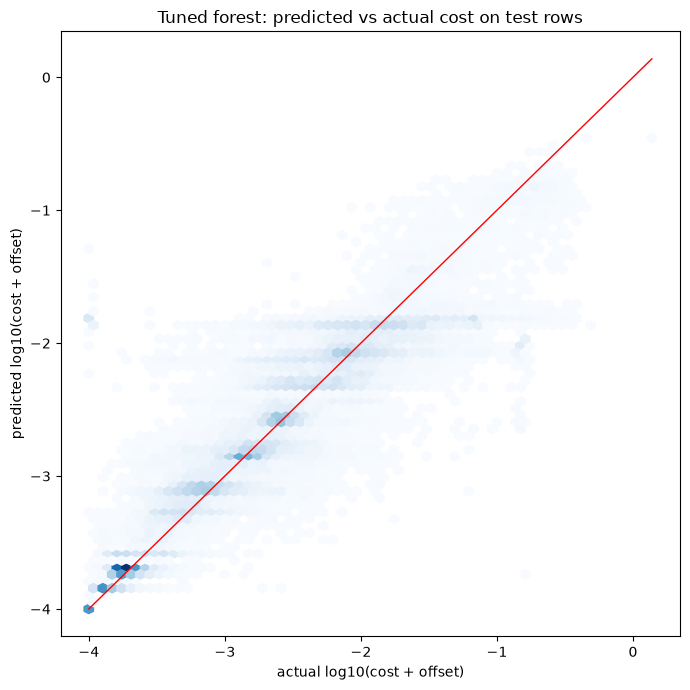

In [3]:
# predicted vs actual on the test rows, log-log
best_reg = rf_reg_search
pred_log = best_reg.predict(test_rows[reg_features])
fig, ax = plt.subplots(figsize=(7, 7))
ax.hexbin(test_rows.log_cost, pred_log, gridsize=60, cmap="Blues", mincnt=1)
lims = [test_rows.log_cost.min(), test_rows.log_cost.max()]
ax.plot(lims, lims, color="red", linewidth=1)
ax.set_xlabel("actual log10(cost + offset)")
ax.set_ylabel("predicted log10(cost + offset)")
ax.set_title("Tuned forest: predicted vs actual cost on test rows")
plt.tight_layout()
plt.show()

Most of the mass hugs the diagonal through the middle of the cost range, which is
where the R2 comes from. The vertical band at the far left is the zero-cost records:
their actual value is pinned at the offset floor (log10 of 0.0001 is exactly -4) while
the model predicts them anywhere along its learned range, since nothing in the
before-the-call features says a response will come back empty.

## Routing with the regressor

A cost regressor does not route by itself, it only prices the menu. To turn it into a
router I paired it with a capability check computed on training prompts only: a model
counts as capable on a task category if it cleared the quality threshold on at least
half of that category's training prompts. The routing rule is then "cheapest predicted
price among capable models." Two categories (hle and swe-bench) have no capable model
under that check, and there the rule falls back to the cheapest model overall, the same
lost-cause logic the label rule uses per prompt.

In [4]:
# capability table from TRAIN prompts only
cap_rate = train_rows.groupby(["dataset", "model"]).score.apply(
    lambda s: (s >= 1.0).mean()).unstack()
capable = cap_rate >= 0.5
cheapest_model = core.groupby("model").cost.mean().idxmin()
print("capable models per dataset:")
print(capable.sum(axis=1))

# price the whole menu for every test prompt with the tuned forest
menu = test_rows.copy()
menu["pred_log_cost"] = best_reg.predict(menu[reg_features])

def pick_for_prompt(group):
    ds = group.dataset.iloc[0]
    ok = capable.loc[ds]
    ok_models = ok[ok].index
    candidates = group[group.model.isin(ok_models)]
    if len(candidates) == 0:
        return cheapest_model
    return candidates.loc[candidates.pred_log_cost.idxmin(), "model"]

reg_picks = menu.groupby("prompt_id").apply(pick_for_prompt, include_groups=False)
print("\nregressor-derived routing, share of traffic per model:")
print(reg_picks.value_counts(normalize=True).round(3).head(8))

capable models per dataset:
dataset
aime             10
arenahard        10
gpqa             13
hle               0
livecodebench    12
livemathbench    12
mmlupro          13
simpleqa          2
swe-bench         0
dtype: int64



regressor-derived routing, share of traffic per model:
qwen3-235b-a22b-2507             0.650
deepseek-v3-0324                 0.240
deepseek-v3.1-terminus           0.073
qwen3-235b-a22b-thinking-2507    0.025
gemini-2.5-pro                   0.011
glm-4.6                          0.001
gemini-2.5-flash                 0.000
Name: proportion, dtype: float64


In [5]:
# economic outcome of regressor-derived routing on the test prompts
lookup = test_rows.set_index(["prompt_id", "model"])[["cost", "score"]]
got = lookup.loc[list(zip(reg_picks.index, reg_picks.values, strict=True))]
print(f"regressor-derived routing -> mean cost {got.cost.mean():.4f}, "
      f"mean score {got.score.mean():.4f}")

out = Path("..") / "data" / "processed"
reg_picks.rename("regressor_routing").reset_index().to_parquet(
    out / "regressor_test_picks.parquet", index=False)
print("saved", len(reg_picks), "picks")

regressor-derived routing -> mean cost 0.0006, mean score 0.5129
saved 2434 picks


The regressor-derived router came out startlingly cheap: $0.0006 per prompt at 0.513
mean score, which beats the always-cheapest baseline on both axes ($0.0008, 0.429).
Picking the predicted-cheapest capable model per prompt undercuts even the cheapest
fixed model, because no single model is the cheapest on every prompt. The honest
caveat: a fixed diet of qwen3-235b-a22b-2507 (where this router already sends 65
percent of traffic) scores 0.538 on these test prompts at $0.0009, so the router's
detours to other budget models cost it quality that the simple strategy keeps. The
dataset-level capability check also cannot rescue hle and swe-bench, where no model
clears the bar and everything falls back to the cheapest model. Both points go into
the head-to-head comparison next.